In [44]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [45]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=toTensor
    )
test_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=toTensor
)

In [46]:
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])
print(len(train_data), len(valid_data), len(test_data))
# from torch.utils.data import TensorDataset
# test_data = TensorDataset(test_data.data, test_data.targets)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

54000 6000 10000


In [47]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 1.158, Train Metric: 0.606, Valid Metric: 0.746
Epoch: 2/20, Loss: 0.612, Train Metric: 0.783, Valid Metric: 0.806
Epoch: 3/20, Loss: 0.522, Train Metric: 0.817, Valid Metric: 0.826
Epoch: 4/20, Loss: 0.483, Train Metric: 0.829, Valid Metric: 0.825
Epoch: 5/20, Loss: 0.46, Train Metric: 0.838, Valid Metric: 0.842
Epoch: 6/20, Loss: 0.443, Train Metric: 0.844, Valid Metric: 0.845
Epoch: 7/20, Loss: 0.43, Train Metric: 0.849, Valid Metric: 0.852
Epoch: 8/20, Loss: 0.418, Train Metric: 0.853, Valid Metric: 0.849
Epoch: 9/20, Loss: 0.407, Train Metric: 0.857, Valid Metric: 0.857
Epoch: 10/20, Loss: 0.398, Train Metric: 0.859, Valid Metric: 0.854
Epoch: 11/20, Loss: 0.389, Train Metric: 0.862, Valid Metric: 0.858
Epoch: 12/20, Loss: 0.383, Train Metric: 0.864, Valid Metric: 0.863
Epoch: 13/20, Loss: 0.376, Train Metric: 0.868, Valid Metric: 0.867
Epoch: 14/20, Loss: 0.37, Train Metric: 0.869, Valid Metric: 0.837
Epoch: 15/20, Loss: 0.365, Train Metric: 0.871, Valid Metric

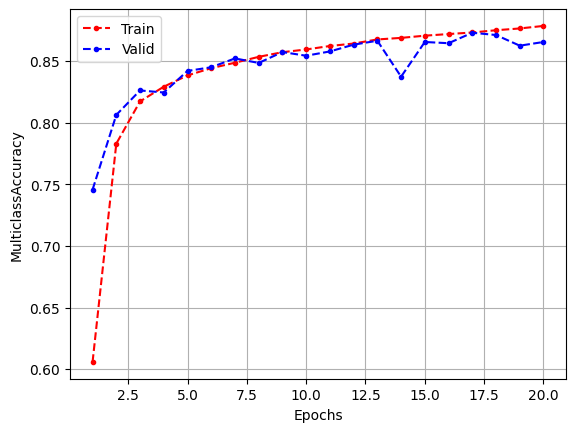

In [49]:
learning_rate = 0.01
n_epochs = 20

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=1*28*28, out_features=30), nn.LeakyReLU(),
    nn.Linear(in_features=30, out_features=50), nn.LeakyReLU(),
    nn.Linear(in_features=50, out_features=10)
)

# class ImageClassifier(nn.Module):
# 	def __init__(self, n_features, n_classes):
# 		super().__init__()
# 		self.stack = nn.Sequential(
# 			nn.Flatten(),
# 			nn.Linear(in_features=n_features, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=n_classes)
# 		)
        
# 	def forward(self, X):
# 		y = self.stack(X)
# 		return y
# model = ImageClassifier(n_features=1*28*28, n_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)